# RE1 - Cifras y figuras del conjunto curado

Recalcula, desde los `.txt` de Raven y por el mismo camino de código que
`src/create_dataset.py` (`domain.annotations`, `domain.dataset`, `utils.audio`), todas
las cifras que cita `docs/RE1_dataset_curado.md`, y renderiza sus figuras en
`research/figures/`.

Complementa a `notebooks/dataset_report.ipynb`, que produce las figuras de
composición y geometría (`annotations_per_pair`, `class_geometry`,
`class_geometry_facets`, `boxes_per_window`, `window_example`). Este cuaderno cubre lo
que el documento de RE1 necesita y aquel no tiene: el embudo de curación con conteos
por regla, la partición real (con ventanas de fondo), el reparto por clase y el
tratamiento de eventos largos.

Correr de arriba a abajo. Las secciones 3 y 5 leen la cabecera de cada grabación, así
que tardan un par de minutos; el resto es inmediato. La última celda escribe
`docs/re1_stats.json`, que es la fuente de todo número citado en el documento.

## 1. Preparación

In [1]:
import json
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path as MplPath

from core.config import P, settings
from core.setup import setup_project_path

setup_project_path(PROJECT_DIR)
FIGURE_DIR = PROJECT_DIR / "research" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR = PROJECT_DIR / "docs"

# Los mismos valores que fija `src/create_dataset.py`.
SEED = 42
MIN_PAIR_COUNT = 100
EMPTY_RATIO = 0.25
RATIOS = (0.600, 0.225, 0.175)
EXCLUDED_PAIRS = {("lw", "cc"), ("sm", "fc"), ("sb", "pcs")}
JOINED_PAIRS = {(("lw", "tr"), ("lw", "tj"), ("lw", "tt"), ("lw", "tf")): ("lw", "trino")}

stats = {}
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print("proyecto:", PROJECT_DIR)

proyecto: /home/nhrot/Prog/tesis-primate


In [2]:
# --- Estilo de las figuras ----------------------------------------------------
# Misma paleta que `dataset_report.ipynb`: superficie clara #fcfcfb, tres series
# categóricas que pasan el piso de contraste en visión normal y en daltonismo.
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]  # train / val / test
CRITICAL = "#d03b3b"  # dato que se pierde
BLUE = "#2a78d6"
BLUE_FADED = "#b7d3f6"

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "savefig.dpi": 200,
        "savefig.bbox": "tight",
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 9,
        "text.color": INK,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 24,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
    }
)


def subtitle(ax, text):
    # Una línea de tinta secundaria bajo el título: el "y qué" de la figura.
    ax.annotate(
        text, xy=(0, 1), xytext=(0, 8), xycoords="axes fraction",
        textcoords="offset points", ha="left", va="bottom", fontsize=8.5, color=INK_2,
    )


def style_value_axis(ax, axis="x"):
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if axis == "x":
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_color(BASELINE)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_color(BASELINE)


_K = 0.5523  # constante del arco circular para una Bézier cúbica


def _square_path(x0, y0, w, h):
    return MplPath(
        [(x0, y0), (x0 + w, y0), (x0 + w, y0 + h), (x0, y0 + h), (x0, y0)],
        [MplPath.MOVETO] + [MplPath.LINETO] * 3 + [MplPath.CLOSEPOLY],
    )


def _rounded_path(x0, y0, w, h, rx, ry, side="right"):
    rx, ry = min(abs(rx), abs(w)), min(abs(ry), abs(h) / 2)
    if rx <= 0 or ry <= 0 or w == 0 or h == 0:
        return _square_path(x0, y0, w, h)
    x1, y1 = x0 + w, y0 + h
    if side == "right":
        verts = [
            (x0, y0), (x1 - rx, y0), (x1 - rx + rx * _K, y0), (x1, y0 + ry - ry * _K),
            (x1, y0 + ry), (x1, y1 - ry), (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1), (x1 - rx, y1), (x0, y1), (x0, y0),
        ]
    else:
        verts = [
            (x0, y0), (x1, y0), (x1, y1 - ry), (x1, y1 - ry + ry * _K),
            (x1 - rx + rx * _K, y1), (x1 - rx, y1), (x0 + rx, y1),
            (x0 + rx - rx * _K, y1), (x0, y1 - ry + ry * _K), (x0, y1 - ry), (x0, y0),
        ]
    codes = [
        MplPath.MOVETO, MplPath.LINETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.LINETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.LINETO, MplPath.CLOSEPOLY,
    ]
    return MplPath(verts, codes)


def _x_per_y(ax):
    box = ax.get_position()
    width_in = ax.figure.get_figwidth() * box.width
    height_in = ax.figure.get_figheight() * box.height
    x_range = abs(np.diff(ax.get_xlim())[0])
    y_range = abs(np.diff(ax.get_ylim())[0])
    return (x_range / width_in) / (y_range / height_in)


def barh(ax, ys, widths, color, height=0.62, left=None, radius_frac=0.30, **kw):
    ys = np.atleast_1d(np.asarray(ys, dtype=float))
    widths = np.asarray(widths, dtype=float)
    left = np.zeros_like(widths) if left is None else np.asarray(left, dtype=float)
    ry = height * radius_frac
    rx = ry * _x_per_y(ax)
    for y, w, x0 in zip(ys, widths, left, strict=True):
        ax.add_patch(
            PathPatch(_rounded_path(x0, y - height / 2, w, h=height, rx=rx, ry=ry, side="right"),
                      facecolor=color, edgecolor="none", **kw)
        )
    return ax


def barv(ax, xs, heights, color, width=0.68, radius_frac=0.30, **kw):
    xs = np.atleast_1d(np.asarray(xs, dtype=float))
    heights = np.asarray(heights, dtype=float)
    rx = width * radius_frac
    ry = rx / _x_per_y(ax)
    for x, h in zip(xs, heights, strict=True):
        ax.add_patch(
            PathPatch(_rounded_path(x - width / 2, 0, width, h, rx, ry, "top"),
                      facecolor=color, edgecolor="none", **kw)
        )
    return ax


def save(fig, name):
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"guardada -> {path.relative_to(PROJECT_DIR)}")

### El corpus de partida

`data/processed/recording_durations.csv` inventaría las grabaciones de `data/cleaned/`
con su duración y si tienen anotación. Es la fuente de la tabla de material de partida
del documento.

In [3]:
durations_path = PROJECT_DIR / "data" / "processed" / "recording_durations.csv"
if durations_path.exists():
    grabaciones = pd.read_csv(durations_path)
    corpus = (
        grabaciones.groupby("species")
        .agg(grabaciones=("duration_s", "size"),
             horas=("duration_s", lambda s: s.sum() / 3600),
             con_anotacion=("has_annotation", "sum"))
        .sort_values("grabaciones", ascending=False)
    )
    stats["corpus"] = {
        "grabaciones": int(len(grabaciones)),
        "horas": float(grabaciones.duration_s.sum() / 3600),
        "con_anotacion": int(grabaciones.has_annotation.sum()),
        "por_especie": [
            {"especie": especie, **{k: float(v) for k, v in fila.items()}}
            for especie, fila in corpus.iterrows()
        ],
    }
    print(f"{len(grabaciones):,} grabaciones | {grabaciones.duration_s.sum() / 3600:.2f} h | "
          f"{int(grabaciones.has_annotation.sum()):,} con anotación")
    display(corpus.round(2))
else:
    print(f"falta {durations_path.name}: la tabla del corpus no se recalcula")

3,350 grabaciones | 32.63 h | 2,815 con anotación


,grabaciones,horas,con_anotacion
species,,,
as,807,7.540,778
sm,659,6.130,582
ac,560,6.060,382
lw,529,5.270,409
pt,375,3.350,320
sb,290,3.080,256
aa,114,1.080,81
cc,16,0.110,7


## 2. Embudo de curación (RE1.1)

`clean_annotations` aplica sus reglas en cadena y devuelve solo lo que sobrevive, así
que aquí se repite la misma secuencia con un contador en cada paso. El orden y las
constantes son los del módulo: `MANUAL_SYNONYMS`, `MANUAL_FIXES`, `MAX_FREQ_HZ`,
`MIN_DURATION_S`.

In [4]:
import logging

from slugify import slugify

from domain.annotations import (
    DROP_COLUMNS,
    MANUAL_FIXES,
    MANUAL_SYNONYMS,
    MAX_FREQ_HZ,
    MIN_DURATION_S,
    NOISE,
)
from domain.species import CALL_TYPES, VALID_PAIRS, Species

logging.getLogger("domain.annotations").setLevel(logging.ERROR)

SOURCE_DIR = settings.data_dir / "cleaned"
funnel = dict.fromkeys(
    ["txt_encontrados", "txt_sin_wav", "txt_con_error", "txt_procesados", "filas_leidas",
     "call_type_nulo", "etiqueta_noise", "renombrados_por_sinonimo", "manual_fixes",
     "recortadas_por_nyquist", "cajas_degeneradas"], 0)

frames = []
paths = sorted(Path(SOURCE_DIR).rglob("*.txt"))
funnel["txt_encontrados"] = len(paths)
for annotation_path in paths:
    wav_path = annotation_path.with_suffix(".wav")
    if not wav_path.exists():
        funnel["txt_sin_wav"] += 1
        continue
    try:
        species_dir = wav_path.parent.name
        for parent in wav_path.parents:
            if "__" in parent.name:
                species_dir = parent.name
                break

        df = pd.read_csv(annotation_path, sep="\t")
        df["audio_path"] = str(wav_path)
        funnel["filas_leidas"] += len(df)

        df.columns = [slugify(col, separator="_") for col in df.columns]
        df = df.drop(columns=DROP_COLUMNS, errors="ignore")

        species = species_dir.split("__")[-1].lower()
        species_enum = next((s for s in Species if s.name.lower() == species), None)
        label_synonyms = (
            {label: code for code, label in CALL_TYPES[species_enum].items()} if species_enum else {}
        )
        normalized = df["call_type"].map(
            lambda v: slugify(v, separator="_") or None if isinstance(v, str) else None
        )
        mapped = normalized.replace(MANUAL_SYNONYMS | label_synonyms)
        funnel["call_type_nulo"] += int(normalized.isna().sum())
        funnel["renombrados_por_sinonimo"] += int((mapped != normalized)[normalized.notna()].sum())

        df["call_type"] = mapped
        df["species"] = species
        funnel["etiqueta_noise"] += int(df["call_type"].eq(NOISE).sum())
        df = df[df["call_type"].notna() & df["call_type"].ne(NOISE)]

        for (bad_sp, bad_ct), (sp, ct) in MANUAL_FIXES.items():
            wrong = df["species"].eq(bad_sp) & df["call_type"].eq(bad_ct)
            funnel["manual_fixes"] += int(wrong.sum())
            df.loc[wrong, ["species", "call_type"]] = [sp, ct]

        pairs = pd.Series(list(zip(df["species"], df["call_type"], strict=True)), index=df.index)
        df["requires_review"] = ~pairs.isin(VALID_PAIRS)

        df["duration_s"] = df["end_time_s"] - df["begin_time_s"]
        funnel["recortadas_por_nyquist"] += int((df["high_freq_hz"] > MAX_FREQ_HZ).sum())
        df["high_freq_hz"] = df["high_freq_hz"].clip(upper=MAX_FREQ_HZ)
        df["bandwidth_hz"] = df["high_freq_hz"] - df["low_freq_hz"]
        usable = (df["duration_s"] >= MIN_DURATION_S) & (df["bandwidth_hz"] > 0)
        funnel["cajas_degeneradas"] += int((~usable).sum())
        frames.append(df[usable].sort_values("begin_time_s").reset_index(drop=True))
        funnel["txt_procesados"] += 1
    except Exception as exc:  # un .txt roto se registra, no detiene el proceso
        funnel["txt_con_error"] += 1
        print("error:", annotation_path.name, exc)

annotations = pd.concat(frames, ignore_index=True)
annotations["pair"] = annotations.species + "/" + annotations.call_type
funnel["anotaciones_curadas"] = len(annotations)

stats["funnel"] = funnel
stats["curado"] = {
    "anotaciones": int(len(annotations)),
    "grabaciones": int(annotations.audio_path.nunique()),
    "especies": int(annotations.species.nunique()),
    "pares": int(annotations.pair.nunique()),
    "pares_en_vocabulario": int(annotations[~annotations.requires_review].pair.nunique()),
    "requires_review": int(annotations.requires_review.sum()),
    "requires_review_frac": float(annotations.requires_review.mean()),
    "pares_fuera_vocabulario": sorted(annotations[annotations.requires_review].pair.unique()),
    "duracion_min_s": float(annotations.duration_s.min()),
    "duracion_max_s": float(annotations.duration_s.max()),
    "duracion_mediana_s": float(annotations.duration_s.median()),
    "bandwidth_min_hz": float(annotations.bandwidth_hz.min()),
    "bandwidth_max_hz": float(annotations.bandwidth_hz.max()),
    "horas_de_evento": float(annotations.duration_s.sum() / 3600),
}
pd.Series(funnel)

txt_encontrados              2831
txt_sin_wav                    16
txt_con_error                   0
txt_procesados               2815
filas_leidas                20075
call_type_nulo                164
etiqueta_noise                866
renombrados_por_sinonimo      105
manual_fixes                   23
recortadas_por_nyquist          8
cajas_degeneradas               3
anotaciones_curadas         19042
dtype: int64

### El subconjunto experimental, tal como lo recorta `select_experiment`

In [5]:
excluded = annotations[["species", "call_type"]].apply(tuple, axis=1).isin(EXCLUDED_PAIRS)
seleccion = {
    "excluidas": int(excluded.sum()),
    "excluidas_por_par": {
        f"{s}/{c}": int(((annotations.species == s) & (annotations.call_type == c)).sum())
        for s, c in sorted(EXCLUDED_PAIRS)
    },
}
candidates = annotations[~excluded].copy()
seleccion["low_freq_elevada_a_fmin"] = int((candidates.low_freq_hz < P.f_min).sum())
candidates["low_freq_hz"] = candidates.low_freq_hz.clip(lower=P.f_min)

for old_pairs, new_pair in JOINED_PAIRS.items():
    for sp, ct in old_pairs:
        joined = (candidates.species == sp) & (candidates.call_type == ct)
        seleccion[f"unidas_{sp}/{ct}"] = int(joined.sum())
        candidates.loc[joined, ["species", "call_type"]] = new_pair
candidates["pair"] = candidates.species + "/" + candidates.call_type

pair_counts = candidates.pair.value_counts()
CLASSES = sorted(pair_counts[pair_counts >= MIN_PAIR_COUNT].index)
experiment = candidates[candidates.pair.isin(CLASSES)].copy()
experiment["label"] = experiment.pair

seleccion.update({
    "pares_candidatos": int(len(pair_counts)),
    "clases": CLASSES,
    "n_clases": len(CLASSES),
    "anotaciones_bajo_umbral": int(len(candidates) - len(experiment)),
    "pares_bajo_umbral": {k: int(v) for k, v in pair_counts[pair_counts < MIN_PAIR_COUNT].items()},
    "anotaciones_experimento": int(len(experiment)),
    "grabaciones_experimento": int(experiment.audio_path.nunique()),
    "especies_experimento": sorted(experiment.species.unique()),
    "horas_de_evento": float(experiment.duration_s.sum() / 3600),
})
stats["seleccion"] = seleccion
stats["conteo_por_clase"] = {k: int(v) for k, v in experiment.pair.value_counts().items()}
print(f"{len(CLASSES)} clases | {len(experiment):,} anotaciones | "
      f"{experiment.audio_path.nunique():,} grabaciones")
print(", ".join(CLASSES))

25 clases | 17,605 anotaciones | 2,669 grabaciones
aa/gc, aa/hm, aa/sc, ac/bc, ac/chc, ac/gc, ac/sc, as/bc, as/hc, lw/cs, lw/sqc, lw/ta, lw/trino, lw/vc, pt/dc, pt/sqc, sb/pcc, sb/ppc, sb/sc, sb/spc, sm/cc, sm/fs, sm/hic, sm/pc, sm/sc


### Figura - el embudo de curación

Cada barra es lo que queda tras la regla de esa fila; en rojo, lo que la regla retira.
Las cuatro primeras son RE1.1 sobre la tabla cruda; las dos últimas son la selección
del experimento, que no corrige datos sino que recorta el alcance.

guardada -> research/figures/re1_curation_funnel.png


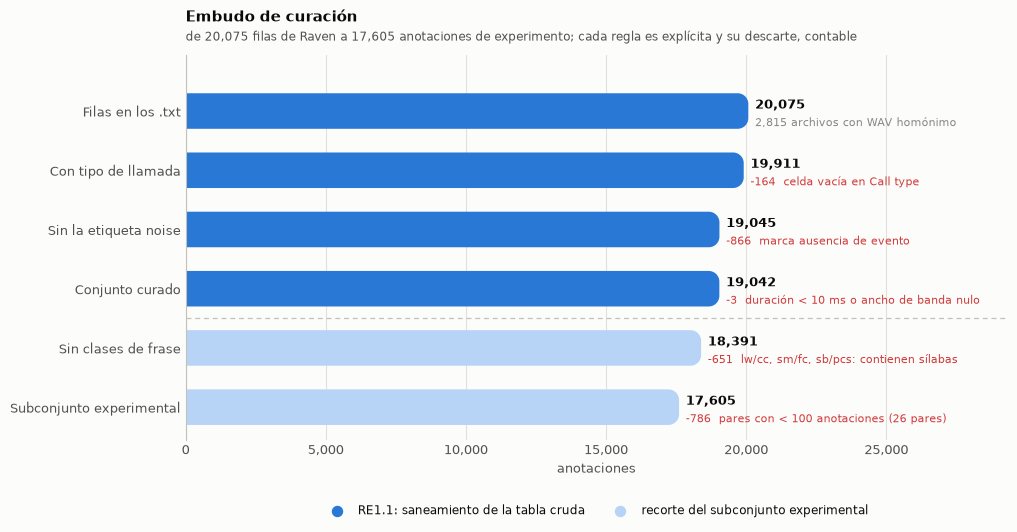

In [6]:
etapas = [
    ("Filas en los .txt", funnel["filas_leidas"], None, f"{funnel['txt_procesados']:,} archivos con WAV homónimo"),
    ("Con tipo de llamada", funnel["filas_leidas"] - funnel["call_type_nulo"],
     funnel["call_type_nulo"], "celda vacía en Call type"),
    ("Sin la etiqueta noise", funnel["filas_leidas"] - funnel["call_type_nulo"] - funnel["etiqueta_noise"],
     funnel["etiqueta_noise"], "marca ausencia de evento"),
    ("Conjunto curado", funnel["anotaciones_curadas"], funnel["cajas_degeneradas"],
     f"duración < {MIN_DURATION_S*1000:.0f} ms o ancho de banda nulo"),
    ("Sin clases de frase", funnel["anotaciones_curadas"] - seleccion["excluidas"],
     seleccion["excluidas"], "lw/cc, sm/fc, sb/pcs: contienen sílabas"),
    ("Subconjunto experimental", seleccion["anotaciones_experimento"],
     seleccion["anotaciones_bajo_umbral"],
     f"pares con < {MIN_PAIR_COUNT} anotaciones ({len(seleccion['pares_bajo_umbral'])} pares)"),
]

fig, ax = plt.subplots(figsize=(10.6, 5.0))
top = etapas[0][1]
ax.set_xlim(0, top * 1.46)
ax.set_ylim(len(etapas) - 0.45, -0.95)
for y, (_nombre, valor, quitado, nota) in enumerate(etapas):
    color = BLUE if y < 4 else BLUE_FADED
    barh(ax, [y], [valor], color, height=0.60)
    ax.text(valor + top * 0.012, y - 0.10, f"{valor:,}", va="center", ha="left",
            fontsize=9.5, color=INK, fontweight="bold")
    if quitado:
        ax.text(valor + top * 0.012, y + 0.20, f"-{quitado:,}  {nota}", va="center",
                ha="left", fontsize=7.6, color=CRITICAL)
    else:
        ax.text(valor + top * 0.012, y + 0.20, nota, va="center", ha="left",
                fontsize=7.6, color=MUTED)

ax.axhline(3.5, color=BASELINE, linewidth=0.9, linestyle=(0, (4, 3)))
ax.scatter([], [], s=52, color=BLUE, label="RE1.1: saneamiento de la tabla cruda")
ax.scatter([], [], s=52, color=BLUE_FADED, label="recorte del subconjunto experimental")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=2)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_yticks(range(len(etapas)))
ax.set_yticklabels([e[0] for e in etapas], fontsize=9)
style_value_axis(ax, "x")
ax.set_xlabel("anotaciones")
ax.set_title("Embudo de curación")
subtitle(ax, f"de {top:,} filas de Raven a {etapas[-1][1]:,} anotaciones de experimento; "
             f"cada regla es explícita y su descarte, contable")
save(fig, "re1_curation_funnel")
plt.show()

## 3. Ventaneo: qué le pasa a cada ventana (RE1.2)

`build_manifest` recorre las ventanas de cada grabación y las clasifica en tres
destinos. La celda repite el bucle con contadores para poder reportar los tres.

Una ventana con un evento presente que no llega al umbral de solapamiento no es
positiva ni de fondo: se descarta, porque etiquetarla como fondo enseñaría al modelo
a callar sobre un evento audible.

In [7]:
import soundfile as sf

from domain.dataset import _boxes_in_window
from domain.species import LabelSet
from utils.audio import window_starts

labels = LabelSet(CLASSES)
destino = {"recorridas": 0, "positivas": 0, "fondo_disponible": 0, "descartadas_evento_parcial": 0}
for audio_path, group in experiment.groupby("audio_path"):
    try:
        duration_s = sf.info(str(audio_path)).duration
    except (RuntimeError, sf.LibsndfileError):
        continue
    class_ids = group["label"].map(labels.id).to_numpy(dtype=np.float64)
    for clip_start_s in window_starts(duration_s, P):
        destino["recorridas"] += 1
        boxes, incomplete = _boxes_in_window(group, class_ids, float(clip_start_s), P)
        if len(boxes):
            destino["positivas"] += 1
        elif not incomplete:
            destino["fondo_disponible"] += 1
        else:
            destino["descartadas_evento_parcial"] += 1

stats["destino_ventanas"] = destino
pd.Series(destino)

recorridas                    57534
positivas                     29564
fondo_disponible              25628
descartadas_evento_parcial     2342
dtype: int64

### El manifiesto y la partición, con la misma semilla que `create_dataset.py`

In [8]:
from domain.dataset import build_manifest, split_manifest

manifest = build_manifest(experiment, labels, empty_ratio=EMPTY_RATIO, seed=SEED)
splits = dict(zip(("train", "val", "test"),
                  split_manifest(manifest, n_classes=len(labels), seed=SEED, ratios=RATIOS),
                  strict=True))

n_pos = sum(1 for w in manifest if len(w.boxes))
stats["manifiesto"] = {
    "ventanas": len(manifest),
    "ventanas_positivas": n_pos,
    "ventanas_de_fondo": len(manifest) - n_pos,
    "fraccion_de_fondo": (len(manifest) - n_pos) / len(manifest),
    "fondo_muestreado_de_disponible": (len(manifest) - n_pos) / destino["fondo_disponible"],
    "cajas": int(sum(len(w.boxes) for w in manifest)),
    "grabaciones": len({w.audio_path for w in manifest}),
    "horas_de_ventana": len(manifest) * P.clip_len_s / 3600,
}

resumen = pd.DataFrame({
    name: {
        "grabaciones": len({w.audio_path for w in split}),
        "ventanas": len(split),
        "positivas": sum(1 for w in split if len(w.boxes)),
        "fondo": sum(1 for w in split if not len(w.boxes)),
        "cajas": int(sum(len(w.boxes) for w in split)),
        "clases": len({int(c) for w in split for c in w.boxes[:, 4]}),
    } for name, split in splits.items()
}).T
resumen["% ventanas"] = 100 * resumen.ventanas / len(manifest)
resumen["% cajas"] = 100 * resumen.cajas / resumen.cajas.sum()
resumen["% grabaciones"] = 100 * resumen.grabaciones / resumen.grabaciones.sum()

grupos = {name: {w.audio_path for w in split} for name, split in splits.items()}
fuga = (grupos["train"] & grupos["val"]) | (grupos["train"] & grupos["test"]) | (grupos["val"] & grupos["test"])
stats["particion"] = {name: {k: float(v) for k, v in row.items()} for name, row in resumen.iterrows()}
stats["particion"]["grabaciones_compartidas"] = len(fuga)
print(f"grabaciones en más de una partición: {len(fuga)}")
resumen.round(2)

grabaciones en más de una partición: 0


,grabaciones,ventanas,positivas,fondo,cajas,clases,% ventanas,% cajas,% grabaciones
train,1314,21966,17381,4585,27022,25,55.720,59.920,49.230
val,728,9446,6734,2712,10090,25,23.960,22.370,27.280
test,627,8007,5449,2558,7985,25,20.310,17.710,23.490


### Figura - composición de las particiones

Izquierda: de qué se compone cada partición. Derecha: la proporción lograda frente a
la pedida. El objetivo se cumple sobre las cajas, que es lo que el algoritmo optimiza;
las ventanas y las grabaciones se desvían porque la unidad de asignación es el archivo
completo y cada archivo trae un número distinto de ambas.

guardada -> research/figures/re1_split_composition.png


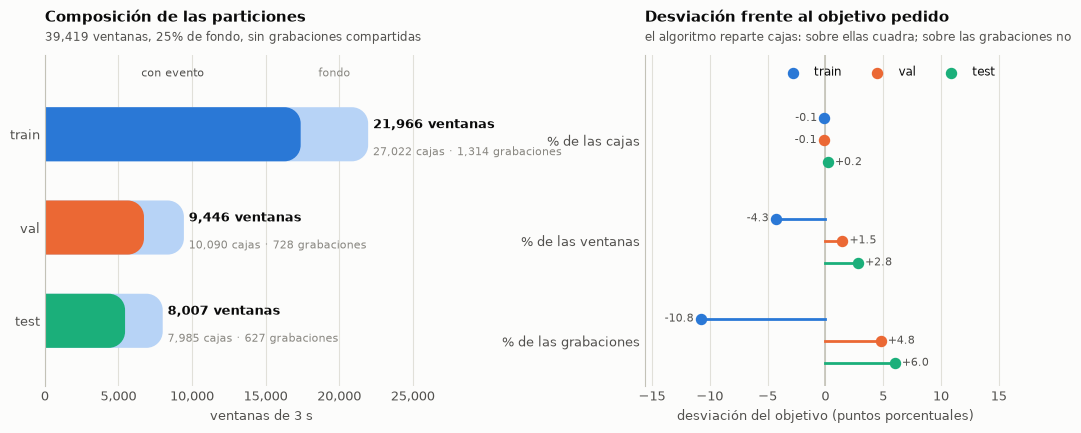

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3), gridspec_kw={"wspace": 0.42, "width_ratios": [1.20, 1]})
names = ["train", "val", "test"]

ax = axes[0]
ax.set_xlim(0, resumen.ventanas.max() * 1.34)
ax.set_ylim(2.7, -0.85)
for y, name in enumerate(names):
    pos, fondo = resumen.loc[name, "positivas"], resumen.loc[name, "fondo"]
    barh(ax, [y], [pos + fondo], BLUE_FADED, height=0.58)
    barh(ax, [y], [pos], SERIES[y], height=0.58)
    ax.text(pos + fondo + resumen.ventanas.max() * 0.015, y - 0.10,
            f"{int(pos + fondo):,} ventanas", va="center", fontsize=9, color=INK, fontweight="bold")
    ax.text(pos + fondo + resumen.ventanas.max() * 0.015, y + 0.19,
            f"{int(resumen.loc[name, 'cajas']):,} cajas · {int(resumen.loc[name, 'grabaciones']):,} grabaciones",
            va="center", fontsize=7.6, color=MUTED)
ax.text(resumen.loc["train", "positivas"] / 2, -0.62, "con evento", ha="center", fontsize=8, color=INK_2)
ax.text(resumen.loc["train", "positivas"] + resumen.loc["train", "fondo"] / 2, -0.62,
        "fondo", ha="center", fontsize=8, color=MUTED)
ax.set_yticks(range(3))
ax.set_yticklabels(names, fontsize=9.5)
style_value_axis(ax, "x")
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_xlabel("ventanas de 3 s")
ax.set_title("Composición de las particiones")
subtitle(ax, f"{stats['manifiesto']['ventanas']:,} ventanas, "
             f"{stats['manifiesto']['fraccion_de_fondo']:.0%} de fondo, sin grabaciones compartidas")

ax = axes[1]
ejes = ["cajas", "ventanas", "grabaciones"]
desviacion = {
    eje: [resumen.loc[n, f"% {eje}"] - objetivo * 100 for n, objetivo in zip(names, RATIOS, strict=True)]
    for eje in ejes
}
lim = max(abs(v) for valores in desviacion.values() for v in valores) * 1.45
ax.set_ylim(len(ejes) - 0.55, -0.85)
ax.set_xlim(-lim, lim)
ax.axvline(0, color=BASELINE, linewidth=1.2, zorder=1)
for y, eje in enumerate(ejes):
    for i, _name in enumerate(names):
        v = desviacion[eje][i]
        yy = y + (i - 1) * 0.22
        ax.plot([0, v], [yy, yy], color=SERIES[i], linewidth=2, zorder=2)
        ax.scatter(v, yy, s=52, color=SERIES[i], zorder=3)
        margen = lim * 0.04 if v >= 0 else -lim * 0.04
        ax.text(v + margen, yy, f"{v:+.1f}", va="center", ha="left" if v >= 0 else "right",
                fontsize=7.6, color=INK_2)
for i, split_name in enumerate(names):
    ax.scatter([], [], s=52, color=SERIES[i], label=split_name)
ax.legend(loc="upper right", ncols=3)
ax.set_yticks(range(len(ejes)))
ax.set_yticklabels([f"% de las {e}" for e in ejes], fontsize=9)
style_value_axis(ax, "x")
ax.set_xlabel("desviación del objetivo (puntos porcentuales)")
ax.set_title("Desviación frente al objetivo pedido")
subtitle(ax, "el algoritmo reparte cajas: sobre ellas cuadra; sobre las grabaciones no")
save(fig, "re1_split_composition")
plt.show()

## 4. Reparto por clase

El algoritmo de `split_manifest` recorre las clases de la más rara a la más común y
asigna cada grabación a la partición con mayor déficit de esa clase. Comprobar que las
25 clases están en las tres particiones, y en qué proporción, es la verificación
central de RE1.2.

In [10]:
por_clase = pd.DataFrame({
    name: pd.Series([labels.name(int(c)) for w in split for c in w.boxes[:, 4]]).value_counts()
    for name, split in splits.items()
}).fillna(0).astype(int)
por_clase["cajas"] = por_clase[names].sum(axis=1)
por_clase["anotaciones"] = experiment.pair.value_counts()
por_clase["cajas/anot"] = por_clase.cajas / por_clase.anotaciones
for name in names:
    por_clase[f"{name} %"] = 100 * por_clase[name] / por_clase.cajas
por_clase = por_clase.sort_values("cajas", ascending=False)

stats["cajas_por_clase"] = [
    {"clase": clase, **{k: float(v) for k, v in row.items()}}
    for clase, row in por_clase.iterrows()
]
stats["desbalance"] = {
    "clase_mayor": por_clase.index[0], "cajas_mayor": int(por_clase.cajas.iloc[0]),
    "clase_menor": por_clase.index[-1], "cajas_menor": int(por_clase.cajas.iloc[-1]),
    "razon": float(por_clase.cajas.iloc[0] / por_clase.cajas.iloc[-1]),
}
por_clase.round(2)

,train,val,test,cajas,anotaciones,cajas/anot,train %,val %,test %
as/hc,6933,2601,2023,11557,1401,8.250,59.990,22.510,17.500
ac/bc,2886,1082,842,4810,2487,1.930,60.000,22.490,17.510
lw/cs,2706,1014,792,4512,2316,1.950,59.970,22.470,17.550
sm/cc,2359,884,688,3931,2040,1.930,60.010,22.490,17.500
as/bc,2233,837,651,3721,1909,1.950,60.010,22.490,17.500
pt/dc,1950,731,568,3249,638,5.090,60.020,22.500,17.480
sb/ppc,1300,463,472,2235,1151,1.940,58.170,20.720,21.120
aa/gc,924,347,269,1540,796,1.930,60.000,22.530,17.470
sb/spc,860,323,251,1434,730,1.960,59.970,22.520,17.500
sm/fs,801,299,232,1332,691,1.930,60.140,22.450,17.420


guardada -> research/figures/re1_boxes_per_class_split.png


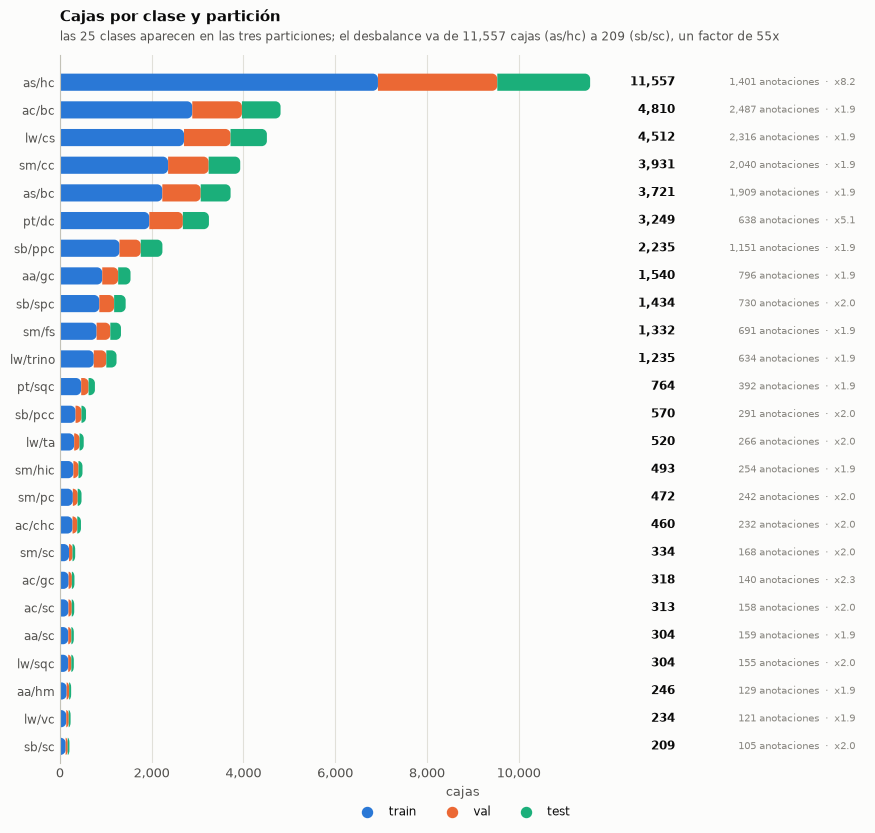

In [11]:
orden = por_clase.index.tolist()
fig, ax = plt.subplots(figsize=(10.4, 9.2))
top = por_clase.cajas.max()
x_total, x_extra = top * 1.16, top * 1.50
ax.set_xlim(0, top * 1.52)
ax.set_ylim(len(orden) - 0.4, -1.0)
for y, clase in enumerate(orden):
    izquierda = 0.0
    for i, name in enumerate(names):
        valor = por_clase.loc[clase, name]
        barh(ax, [y], [valor], SERIES[i], height=0.62, left=[izquierda])
        izquierda += valor
    ax.text(x_total, y, f"{int(izquierda):,}", va="center", ha="right",
            fontsize=8.4, color=INK, fontweight="bold")
    ax.text(x_extra, y,
            f"{int(por_clase.loc[clase, 'anotaciones']):,} anotaciones  ·  x{por_clase.loc[clase, 'cajas/anot']:.1f}",
            va="center", ha="right", fontsize=7.4, color=MUTED)

for i, name in enumerate(names):
    ax.scatter([], [], s=52, color=SERIES[i], label=name)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.045), ncols=3)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_xticks(np.arange(0, top + 1, 2000))
ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden, fontsize=8.5)
style_value_axis(ax, "x")
ax.set_xlabel("cajas")
ax.set_title("Cajas por clase y partición")
d = stats["desbalance"]
subtitle(ax, f"las 25 clases aparecen en las tres particiones; el desbalance va de "
             f"{d['cajas_mayor']:,} cajas ({d['clase_mayor']}) a {d['cajas_menor']:,} "
             f"({d['clase_menor']}), un factor de {d['razon']:.0f}x")
save(fig, "re1_boxes_per_class_split")
plt.show()

## 5. Eventos largos: la regla vigente

El criterio de asignación compara el solapamiento contra
`visible = min(duración, longitud del clip)`, no contra la duración completa. La
diferencia decide qué pasa con los eventos que superan la ventana: con la duración
completa, nada de más de 6 s podría entrar en ninguna ventana; con la parte visible,
un evento largo entrega una caja recortada en cada ventana que contenga al menos
1,5 s de él.

El panel derecho mide el precio: la fracción de cajas de cada clase que toca un borde
temporal de su ventana y la fracción que ocupa la ventana entera. Una caja de ancho
completo no delimita el evento, solo declara que la ventana está dentro de él.

In [12]:
cajas = []
for split_name, split in splits.items():
    for w in split:
        for cx, cy, ww, hh, cid in w.boxes:
            cajas.append((split_name, labels.name(int(cid)), cx, cy, ww, hh))
cajas = pd.DataFrame(cajas, columns=["split", "clase", "cx", "cy", "w", "h"])
cajas["x0"] = cajas.cx - cajas.w / 2
cajas["x1"] = cajas.cx + cajas.w / 2
cajas["en_borde"] = (cajas.x0 <= 1e-9) | (cajas.x1 >= 1 - 1e-9)
cajas["ancho_completo"] = cajas.w >= 0.999

borde = cajas.groupby("clase").agg(cajas=("w", "size"), en_borde=("en_borde", "mean"),
                                   ancho_completo=("ancho_completo", "mean"))
borde = borde.reindex(orden)
stats["recorte_por_clase"] = [
    {"clase": c, "cajas": int(r.cajas), "en_borde": float(r.en_borde),
     "ancho_completo": float(r.ancho_completo)} for c, r in borde.iterrows()
]
stats["recorte"] = {
    "cajas": int(len(cajas)),
    "en_borde": float(cajas.en_borde.mean()),
    "ancho_completo": float(cajas.ancho_completo.mean()),
    "anotaciones_sobre_clip": int((experiment.duration_s > P.clip_len_s).sum()),
    "anotaciones_sobre_doble_clip": int((experiment.duration_s > 2 * P.clip_len_s).sum()),
}
print(f"{len(cajas):,} cajas | en borde {cajas.en_borde.mean():.1%} | "
      f"ancho completo {cajas.ancho_completo.mean():.1%}")
borde.head(8).round(3)

45,097 cajas | en borde 40.6% | ancho completo 24.6%


,cajas,en_borde,ancho_completo
clase,,,
as/hc,11557,0.996,0.774
ac/bc,4810,0.121,0.000
lw/cs,4512,0.139,0.000
sm/cc,3931,0.025,0.000
as/bc,3721,0.114,0.001
pt/dc,3249,0.992,0.634
sb/ppc,2235,0.078,0.000
aa/gc,1540,0.036,0.000


guardada -> research/figures/re1_long_events.png


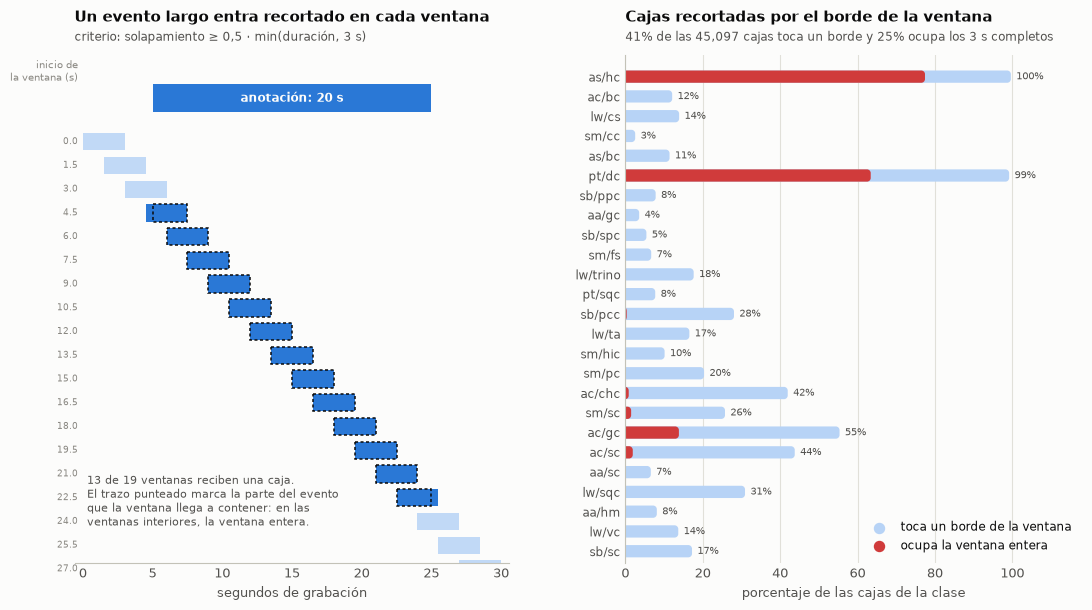

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.6),
                         gridspec_kw={"wspace": 0.26, "width_ratios": [1, 1.05]})

# --- izquierda: la regla sobre un evento largo real --------------------------
ax = axes[0]
evento = (5.0, 25.0)  # un aullido de 20 s dentro de una grabación de 30 s
grabacion = 30.0
ax.set_xlim(-0.6, grabacion + 0.6)
ax.set_ylim(15.6, -2.6)
ax.add_patch(Rectangle((evento[0], -1.55), evento[1] - evento[0], 1.0,
                       facecolor=BLUE, edgecolor="none"))
ax.text((evento[0] + evento[1]) / 2, -1.05, "anotación: 20 s", ha="center", va="center",
        fontsize=8.5, color=SURFACE, fontweight="bold")

con_caja = 0
for i, inicio in enumerate(window_starts(grabacion, P)):
    fin = inicio + P.clip_len_s
    solape = min(fin, evento[1]) - max(inicio, evento[0])
    visible = min(evento[1] - evento[0], P.clip_len_s)
    entra = solape > 0 and solape >= P.min_overlap * visible
    con_caja += bool(entra)
    color = SERIES[0] if entra else BLUE_FADED
    ax.add_patch(Rectangle((inicio, i * 0.85 + 0.2), P.clip_len_s, 0.62,
                           facecolor=color, edgecolor="none", alpha=1.0 if entra else 0.85))
    if entra:
        x0 = max(inicio, evento[0])
        x1 = min(fin, evento[1])
        ax.add_patch(Rectangle((x0, i * 0.85 + 0.2), x1 - x0, 0.62, facecolor="none",
                               edgecolor=INK, linewidth=1.1, linestyle=(0, (2, 1.6))))
    ax.text(-0.35, i * 0.85 + 0.51, f"{inicio:.1f}", ha="right", va="center",
            fontsize=6.6, color=MUTED)

ax.text(0.3, 12.4, f"{con_caja} de {len(window_starts(grabacion, P))} ventanas reciben una caja.\n"
        "El trazo punteado marca la parte del evento\nque la ventana llega a contener: en las\n"
        "ventanas interiores, la ventana entera.",
        fontsize=8, color=INK_2, ha="left", va="top")
ax.set_yticks([])
ax.text(-0.35, -2.0, "inicio de\nla ventana (s)", fontsize=7.4, color=MUTED, ha="right", va="center")
ax.set_xlabel("segundos de grabación")
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.set_title("Un evento largo entra recortado en cada ventana")
subtitle(ax, "criterio: solapamiento ≥ 0,5 · min(duración, 3 s)")

# --- derecha: el precio, por clase -------------------------------------------
ax = axes[1]
ys = np.arange(len(borde))
ax.set_xlim(0, 118)
ax.set_ylim(len(borde) - 0.4, -1.1)
for y, (_clase, fila) in zip(ys, borde.iterrows(), strict=True):
    barh(ax, [y], [100 * fila.en_borde], BLUE_FADED, height=0.62)
    barh(ax, [y], [100 * fila.ancho_completo], CRITICAL, height=0.62)
    ax.text(100 * fila.en_borde + 1.4, y, f"{fila.en_borde:.0%}", va="center",
            fontsize=7.4, color=INK_2)
ax.scatter([], [], s=52, color=BLUE_FADED, label="toca un borde de la ventana")
ax.scatter([], [], s=52, color=CRITICAL, label="ocupa la ventana entera")
ax.legend(loc="lower right")
ax.set_yticks(ys)
ax.set_yticklabels(borde.index, fontsize=8.5)
style_value_axis(ax, "x")
ax.set_xlabel("porcentaje de las cajas de la clase")
ax.set_title("Cajas recortadas por el borde de la ventana")
subtitle(ax, f"{cajas.en_borde.mean():.0%} de las {len(cajas):,} cajas toca un borde y "
             f"{cajas.ancho_completo.mean():.0%} ocupa los 3 s completos")
save(fig, "re1_long_events")
plt.show()

## 6. Geometría de las cajas normalizadas

Lo que el detector tiene que regresar: ancho y alto en el marco normalizado, después
del ventaneo y del mapa mel de `hz_to_y`. La nube fija el rango de escalas que el
decodificador debe cubrir y justifica la pirámide multiescala del Capítulo de
detección.

guardada -> research/figures/re1_box_geometry.png


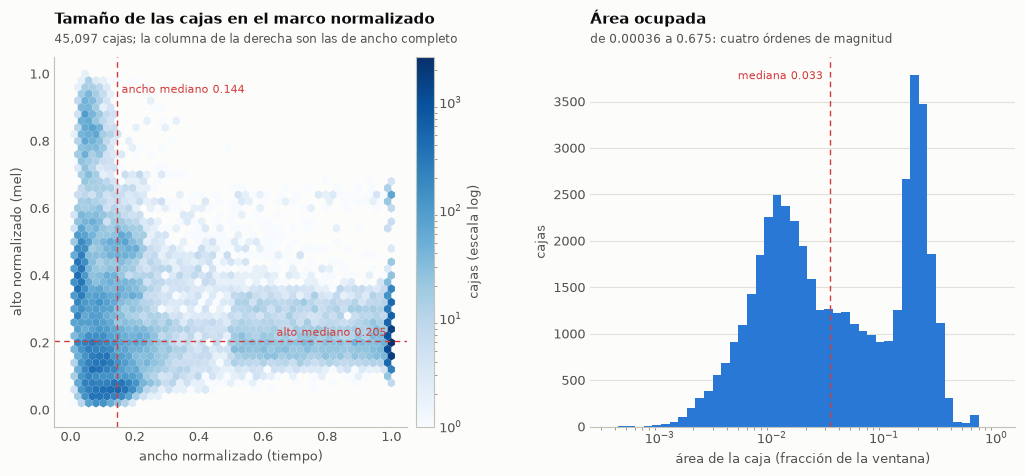

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), gridspec_kw={"wspace": 0.26})

ax = axes[0]
hb = ax.hexbin(cajas.w, cajas.h, gridsize=44, bins="log", cmap="Blues", mincnt=1,
               extent=(0, 1, 0, 1), linewidths=0)
ax.axvline(cajas.w.median(), color=CRITICAL, linewidth=1, linestyle=(0, (4, 3)))
ax.axhline(cajas.h.median(), color=CRITICAL, linewidth=1, linestyle=(0, (4, 3)))
ax.text(cajas.w.median() + 0.015, 0.97, f"ancho mediano {cajas.w.median():.3f}",
        fontsize=7.6, color=CRITICAL, va="top")
ax.text(0.985, cajas.h.median() + 0.015, f"alto mediano {cajas.h.median():.3f}",
        fontsize=7.6, color=CRITICAL, ha="right")
ax.set_xlabel("ancho normalizado (tiempo)")
ax.set_ylabel("alto normalizado (mel)")
ax.set_title("Tamaño de las cajas en el marco normalizado")
subtitle(ax, f"{len(cajas):,} cajas; la columna de la derecha son las de ancho completo")
fig.colorbar(hb, ax=ax, label="cajas (escala log)", pad=0.02)

ax = axes[1]
area = cajas.w * cajas.h
bins = np.logspace(np.log10(max(area.min(), 1e-5)), 0, 46)
ax.hist(area, bins=bins, color=BLUE, edgecolor="none")
ax.set_xscale("log")
ax.axvline(area.median(), color=CRITICAL, linewidth=1, linestyle=(0, (4, 3)))
ax.text(area.median() / 1.15, ax.get_ylim()[1] * 0.94, f"mediana {area.median():.3f}",
        fontsize=7.8, color=CRITICAL, ha="right")
style_value_axis(ax, "y")
ax.set_xlabel("área de la caja (fracción de la ventana)")
ax.set_ylabel("cajas")
ax.set_title("Área ocupada")
subtitle(ax, f"de {area.min():.5f} a {area.max():.3f}: cuatro órdenes de magnitud")
stats["geometria_cajas"] = {
    "ancho_mediano": float(cajas.w.median()), "alto_mediano": float(cajas.h.median()),
    "ancho_min": float(cajas.w.min()), "alto_min": float(cajas.h.min()),
    "area_mediana": float(area.median()), "area_min": float(area.min()), "area_max": float(area.max()),
}
save(fig, "re1_box_geometry")
plt.show()

## 7. Los artefactos que hay en disco

Comprueba que `data/processed/` corresponde a lo que este cuaderno acaba de
recalcular: mismo número de ventanas, mismas cajas, mismas clases. `mmap=True` lee la
cabecera del tensor sin traer los gigabytes de imágenes a memoria.

In [15]:
import torch

CACHE_DIR = PROJECT_DIR / "data" / "processed"
artefactos = {}
if (CACHE_DIR / "meta.json").exists():
    meta = json.loads((CACHE_DIR / "meta.json").read_text())
    labels_json = json.loads((CACHE_DIR / "labels.json").read_text())
    for name in names:
        path = CACHE_DIR / f"{name}.pt"
        if not path.exists():
            continue
        cache = torch.load(path, map_location="cpu", mmap=True, weights_only=False)
        artefactos[name] = {
            "GB": path.stat().st_size / 1024**3,
            "imagenes": list(cache["images"].shape),
            "dtype": str(cache["images"].dtype),
            "cajas": int(sum(len(t) for t in cache["labels"])),
            "ventanas_de_fondo": int(sum(1 for t in cache["labels"] if len(t) == 0)),
            "clases": len({int(c) for t in cache["labels"] for c in t.tolist()}),
        }
        del cache
    stats["artefactos"] = artefactos
    stats["meta_json"] = meta
    stats["labels_json"] = labels_json
    coincide = all(
        artefactos[name]["imagenes"][0] == resumen.loc[name, "ventanas"]
        and artefactos[name]["cajas"] == resumen.loc[name, "cajas"]
        for name in artefactos
    )
    print("¿el disco coincide con lo recalculado?", "sí" if coincide else "NO")
    print("clases en labels.json:", len(labels_json), "| iguales a las recalculadas:",
          list(labels_json.values()) == CLASSES)
    display(pd.DataFrame(artefactos).T)
else:
    print(f"no hay caché en {CACHE_DIR}; corré `python src/create_dataset.py`")

¿el disco coincide con lo recalculado? sí
clases en labels.json: 25 | iguales a las recalculadas: True


,GB,imagenes,dtype,cajas,ventanas_de_fondo,clases
train,3.477,"[21966, 1, 128, 331]",torch.float32,27022,4585,25
val,1.495,"[9446, 1, 128, 331]",torch.float32,10090,2712,25
test,1.267,"[8007, 1, 128, 331]",torch.float32,7985,2558,25


## 8. Todas las cifras del documento

Escribe `docs/re1_stats.json`. Cada número citado en `docs/RE1_dataset_curado.md` sale
de este archivo; volver a correr el cuaderno tras cambiar los datos o `Parameters` lo
actualiza.

In [16]:
(DOCS_DIR / "re1_stats.json").write_text(json.dumps(stats, indent=2, ensure_ascii=False))
print("escrito ->", (DOCS_DIR / "re1_stats.json").relative_to(PROJECT_DIR))

f, c, s, m = stats["funnel"], stats["curado"], stats["seleccion"], stats["manifiesto"]
resumen_txt = [
    f"archivos .txt / con WAV       {f['txt_encontrados']:,} / {f['txt_procesados']:,}",
    f"filas leídas                  {f['filas_leidas']:,}",
    f"  sin tipo de llamada         {f['call_type_nulo']:,}",
    f"  etiqueta noise              {f['etiqueta_noise']:,}",
    f"  cajas degeneradas           {f['cajas_degeneradas']:,}",
    f"  renombradas por sinónimo    {f['renombrados_por_sinonimo']:,}",
    f"  corregidas (MANUAL_FIXES)   {f['manual_fixes']:,}",
    f"  recortadas a Nyquist        {f['recortadas_por_nyquist']:,}",
    f"anotaciones curadas           {c['anotaciones']:,}",
    f"grabaciones / especies        {c['grabaciones']:,} / {c['especies']}",
    f"pares (en vocabulario)        {c['pares']} ({c['pares_en_vocabulario']})",
    f"requires_review               {c['requires_review']:,} ({c['requires_review_frac']:.1%})",
    f"duración mín/mediana/máx      {c['duracion_min_s']:.3f} s / {c['duracion_mediana_s']:.3f} s / {c['duracion_max_s']:.1f} s",
    f"horas de evento               {c['horas_de_evento']:.2f} h",
    f"clases del experimento        {s['n_clases']}",
    f"anotaciones del experimento   {s['anotaciones_experimento']:,} en {s['grabaciones_experimento']:,} grabaciones",
    f"ventanas positivas / fondo    {m['ventanas_positivas']:,} / {m['ventanas_de_fondo']:,}",
    f"ventanas totales / cajas      {m['ventanas']:,} / {m['cajas']:,}",
    f"horas de ventana              {m['horas_de_ventana']:.1f} h",
]
print("\n".join(resumen_txt))

escrito -> docs/re1_stats.json
archivos .txt / con WAV       2,831 / 2,815
filas leídas                  20,075
  sin tipo de llamada         164
  etiqueta noise              866
  cajas degeneradas           3
  renombradas por sinónimo    105
  corregidas (MANUAL_FIXES)   23
  recortadas a Nyquist        8
anotaciones curadas           19,042
grabaciones / especies        2,789 / 8
pares (en vocabulario)        57 (41)
requires_review               328 (1.7%)
duración mín/mediana/máx      0.034 s / 0.343 s / 73.3 s
horas de evento               8.60 h
clases del experimento        25
anotaciones del experimento   17,605 en 2,669 grabaciones
ventanas positivas / fondo    29,564 / 9,855
ventanas totales / cajas      39,419 / 45,097
horas de ventana              32.8 h
